In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

In [87]:
# Load and combine all trainning and evaluation .csv files
metrics_path = Path("metrics")

train_files = list(metrics_path.glob("train_*.csv"))
eval_files = list(metrics_path.glob("eval_*.csv"))

train_df = pd.concat([pd.read_csv(i) for i in train_files], ignore_index=True)
eval_df = pd.concat([pd.read_csv(i) for i in eval_files], ignore_index=True)

# Print df structure
print("Train shape:", train_df.shape)
print("Eval shape:", eval_df.shape)
print("\nColumns:", train_df.columns.tolist())
train_df.head()

Train shape: (2245, 14)
Eval shape: (4320, 7)

Columns: ['train_step', 'method', 'seed', 'current_difficulty', 'target_difficulty_steps', 'eval_difficulty', 'eval_mode', 'eval_rap', 'mean_reward', 'std_reward', 'win_rate', 'threshold_hit', 'stage_steps', 'stage_index']


,train_step,method,seed,current_difficulty,target_difficulty_steps,eval_difficulty,eval_mode,eval_rap,mean_reward,std_reward,win_rate,threshold_hit,stage_steps,stage_index
0,50000,curriculum,42,0,0,0,0,0.25,-21.0,0.0,0.0,0,50000,0
1,100000,curriculum,42,0,0,0,0,0.25,-21.0,0.0,0.0,0,100000,0
2,150000,curriculum,42,0,0,0,0,0.25,-21.0,0.0,0.0,0,150000,0
3,200000,curriculum,42,0,0,0,0,0.25,-21.0,0.0,0.0,0,200000,0
4,250000,curriculum,42,0,0,0,0,0.25,-20.8,0.4,0.0,0,250000,0


In [88]:
# Validate our data, check our number of entries per method and seed
counts = train_df.groupby(["method", "seed"]).size()
print(counts)

# Ensures curriculum progression's ordered correctly
print()
for (method, seed), df in train_df.groupby(["method", "seed"]):
    if not df["target_difficulty_steps"].is_monotonic_increasing:
        print(f"Non-monotonic target steps: {method}, seed {seed}")

# Check max training step per seed
max_steps = train_df.groupby(["method", "seed"])["train_step"].max()
print("\nMax train steps:\n", max_steps)

method      seed
curriculum  42       500
            43       500
            44      1002
direct      42       119
            43        62
            44        62
dtype: int64

Non-monotonic target steps: curriculum, seed 44
Non-monotonic target steps: direct, seed 42

Max train steps:
 method      seed
curriculum  42      25000000
            43      25000000
            44      25000968
direct      42      30530080
            43      24800000
            44      24800000
Name: train_step, dtype: int64


In [89]:
# Sort data
train_df = train_df.sort_values(["method", "seed", "train_step"])

# Truncate all runs to same max step (ensures a fair comparison)
min_max_step = train_df.groupby(["method", "seed"])["train_step"].max().min()

train_df = train_df[train_df["train_step"] <= min_max_step]

print("Using the common maximum step:", min_max_step)

Using the common maximum step: 24800000


In [90]:
# Helper functions

# Compute area under the learning curve (overall performance)
def compute_auc(x, y):
    return np.trapz(y, x)

# Measure sample efficiency (steps needed to reach threshold)
def time_to_threshold(df, threshold=15):
    reached = df[df["mean_reward"] >= threshold]
    return reached["train_step"].iloc[0] if len(reached) > 0 else np.nan

# Final performance (end of training)
def final_reward(df):
    return df.iloc[-1]["mean_reward"]

# Initial performances
def jumpstart_reward(df):
    return df.iloc[0]["mean_reward"]

In [91]:
# Compute metrics per seed for each mehtod
seed_rows = []

for (method, seed), df in train_df.groupby(["method", "seed"]):    
    auc = compute_auc(df["train_step"], df["mean_reward"])
    seed_rows.append({"method": method, "seed": seed, "auc": auc, "time_to_threshold": time_to_threshold(df), "final_reward": final_reward(df), "jumpstart": jumpstart_reward(df)})

seed_df = pd.DataFrame(seed_rows)
seed_df

,method,seed,auc,time_to_threshold,final_reward,jumpstart
0,curriculum,42,338790000.0,3450000,19.6,-21.0
1,curriculum,43,308867500.0,5850000,17.1,-21.0
2,curriculum,44,272109985.2,3450000,18.3,-21.0
3,direct,42,363040000.0,4400000,17.6,-21.0
4,direct,43,385620000.0,2000000,17.1,-21.0
5,direct,44,345620000.0,4000000,17.5,-21.0


In [92]:
# Print perfomance across seed (mean and std)
summary_df = seed_df.groupby("method").agg(["mean", "std"])
summary_df

seed                auc               time_to_threshold  \
            mean  std          mean           std              mean   
method                                                                
curriculum  43.0  1.0  3.065892e+08  3.339834e+07      4.250000e+06   
direct      43.0  1.0  3.647600e+08  2.005539e+07      3.466667e+06   

                         final_reward           jumpstart       
                     std         mean       std      mean  std  
method                                                          
curriculum  1.385641e+06    18.333333  1.250333     -21.0  0.0  
direct      1.285820e+06    17.400000  0.264575     -21.0  0.0

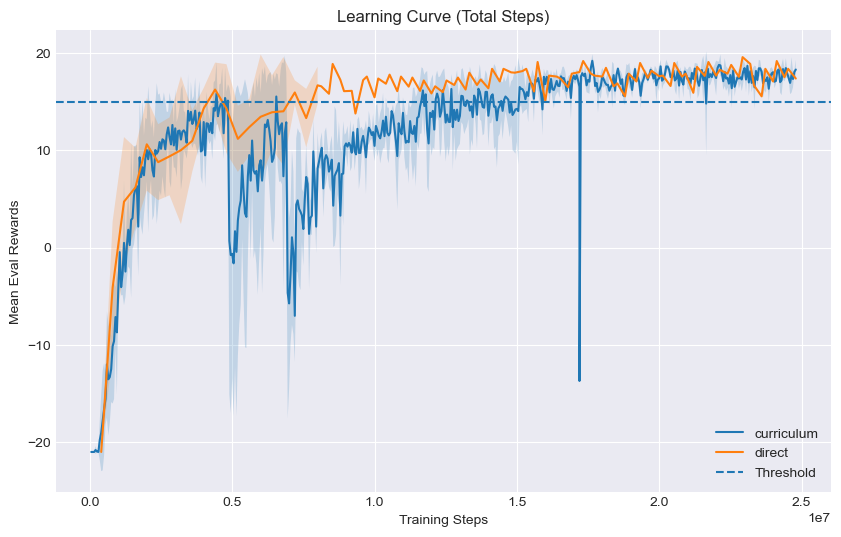

In [93]:
# Plot learning curves (w/ variability)
plt.figure(figsize=(10,6))

for method, df in train_df.groupby("method"):
    grouped = df.groupby("train_step")["mean_reward"].agg(["mean", "std"])
    
    plt.plot(grouped.index, grouped["mean"], label=method)
    plt.fill_between(grouped.index, grouped["mean"] - grouped["std"], grouped["mean"] + grouped["std"], alpha=0.2)

plt.axhline(15, linestyle="--", label="Threshold") # performance threshold reference (cue for sucess)
plt.xlabel("Training Steps")
plt.ylabel("Mean Eval Rewards")
plt.title("Learning Curve (Total Steps)")
plt.legend()
plt.show()

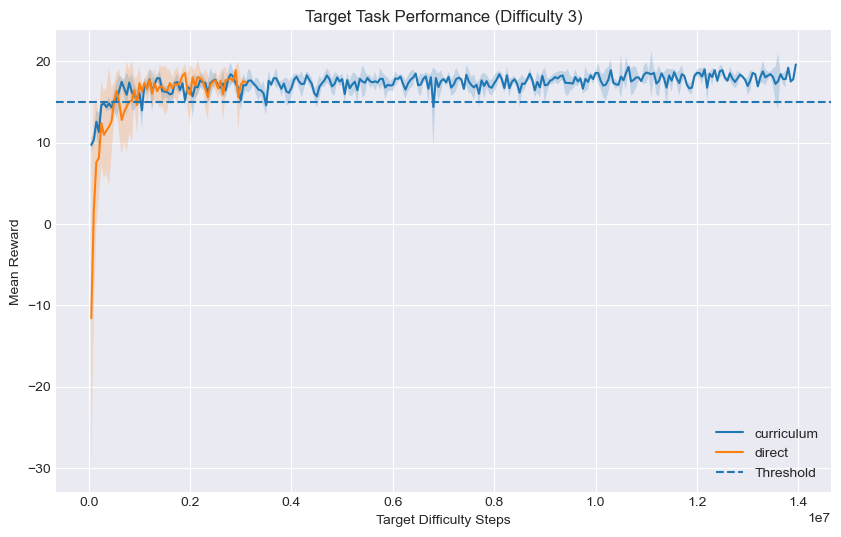

In [94]:
# Plot performance on target difficulty (d=3, i.e., difficulty 3)
target_df = train_df[train_df["eval_difficulty"] == 3]

plt.figure(figsize=(10,6))

for method, df in target_df.groupby("method"):
    grouped = df.groupby("target_difficulty_steps")["mean_reward"].agg(["mean", "std"])
    
    plt.plot(grouped.index, grouped["mean"], label=method)
    plt.fill_between(grouped.index, grouped["mean"] - grouped["std"], grouped["mean"] + grouped["std"], alpha=0.2)

plt.axhline(15, linestyle="--", label="Threshold") # performance threshold reference (cue for sucess)
plt.xlabel("Target Difficulty Steps")
plt.ylabel("Mean Reward")
plt.title("Target Task Performance (Difficulty 3)")
plt.legend()
plt.show()

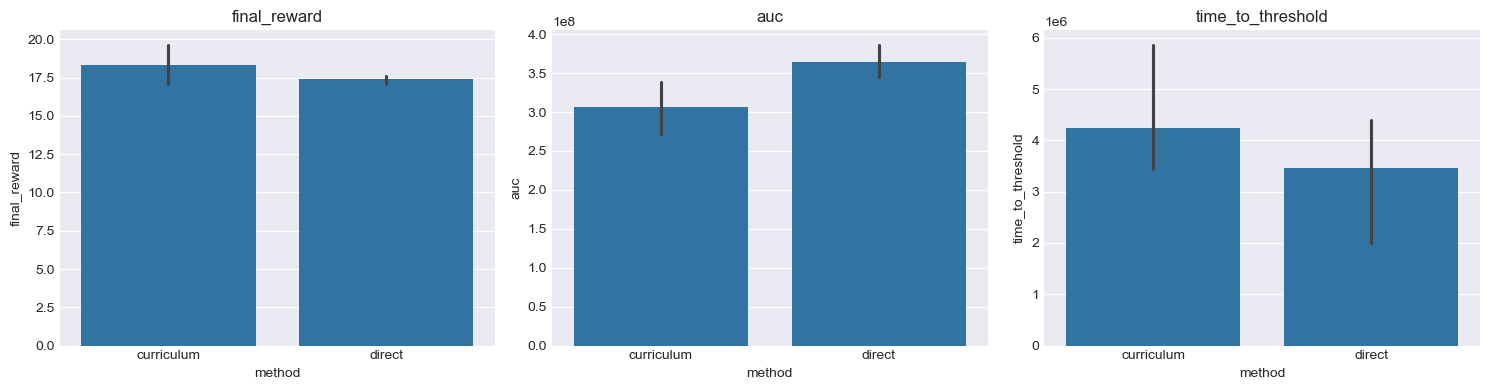

In [95]:
# Summary bar charts (comparing metrics between methods/algorithms)
fig, axes = plt.subplots(1, 3, figsize=(15,4))

metrics = ["final_reward", "auc", "time_to_threshold"]

for i, metric in enumerate(metrics):
    sns.barplot(data=seed_df, x="method", y=metric, ax=axes[i])
    axes[i].set_title(metric)

plt.tight_layout()
plt.show()

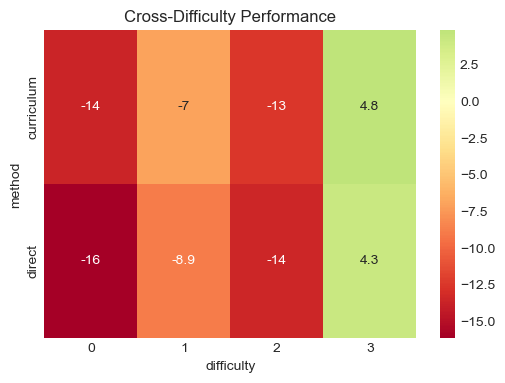

In [99]:
# Compute average reward across methods and difficulty levels
heat_df = eval_df.groupby(["method", "difficulty"])["reward"].mean().reset_index()

pivot = heat_df.pivot(index="method", columns="difficulty", values="reward")

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="RdYlGn", center=0)
plt.title("Cross-Difficulty Performance")
plt.show()

In [97]:
# Perform statistical comparison between methods (final reward)
curr = seed_df[seed_df.method == "curriculum"]["final_reward"]
direct = seed_df[seed_df.method == "direct"]["final_reward"]

t, p = stats.ttest_ind(curr, direct)
print("p-value:", p)

# Computing effect size
d = (curr.mean() - direct.mean()) / np.sqrt((curr.std()**2 + direct.std()**2)/2)
print("Cohen's d:", d)

p-value: 0.2745766290948496
Cohen's d: 1.0327955589886408
